
========== HISTORICAL DATA ==========
           SERIES      OPEN      HIGH       LOW PREV. CLOSE       LTP   CLOSE  \
DATE                                                                            
2026-07-29     EQ  1,147.00  1,164.50  1,128.40    1,105.70  1,153.50  1155.6   
2026-07-30     EQ  1,168.00  1,187.70  1,151.30    1,155.60  1,155.00  1155.1   
2026-07-31     EQ  1,118.90  1,139.30  1,107.20    1,155.10  1,129.90  1130.1   
2026-08-03     EQ  1,145.10  1,180.00  1,138.10    1,130.10  1,180.00  1180.0   
2026-08-04     EQ  1,168.00  1,175.70  1,153.30    1,180.00  1,167.50  1167.5   

                VWAP 52 WEEK HIGH  52 WEEK LOW       VOLUME  \
DATE                                                          
2026-07-29  1,152.38     1,728.00        982.4  3,44,00,369   
2026-07-30  1,173.03     1,728.00        982.4  2,26,30,218   
2026-07-31  1,128.12     1,728.00        982.4  1,43,67,075   
2026-08-03  1,160.88     1,728.00        982.4    85,82,270   
2026-08-04  1,1

C:\Users\pravi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\pravi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\pravi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\pravi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\pravi\AppData\Local\Programs\Python\Python310\lib\s


--- NEXT 5 TRADING DAY FORECAST ---
               Forecast     Lower_CI     Upper_CI
2026-08-31  1136.453462  1101.408527  1171.498397
2026-09-01  1135.575862  1092.429688  1178.722036
2026-09-02  1135.473804  1086.092215  1184.855394
2026-09-03  1135.461936  1080.606748  1190.317124
2026-09-04  1135.460556  1075.636646  1195.284465


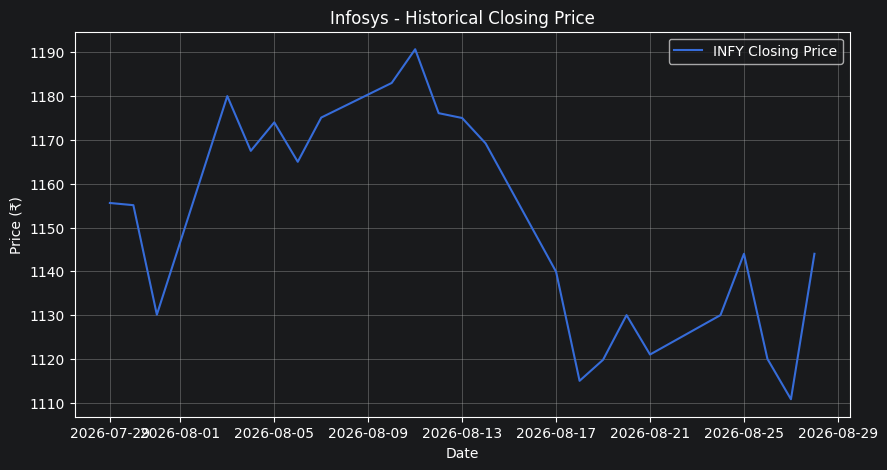

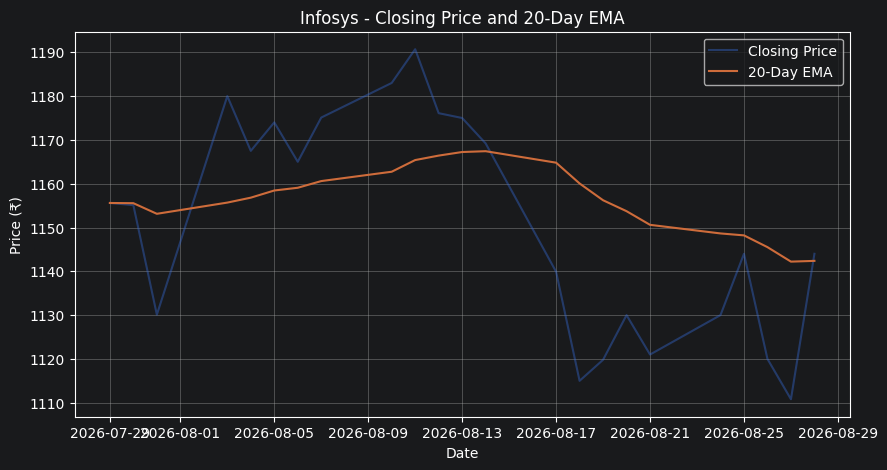

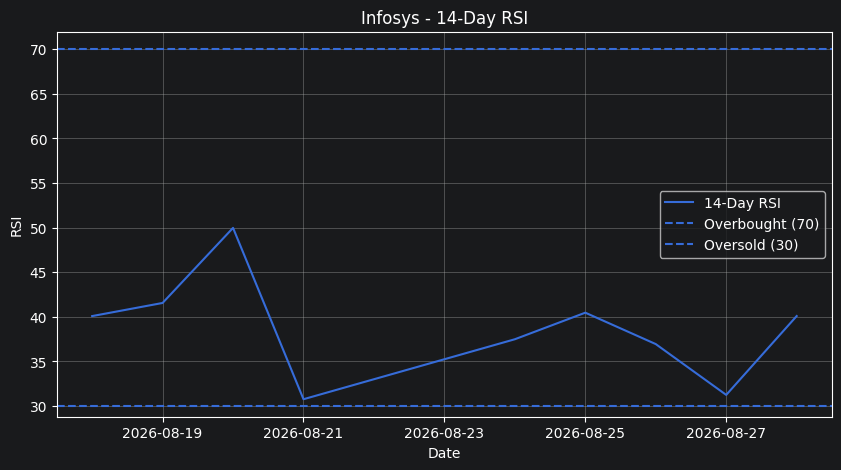

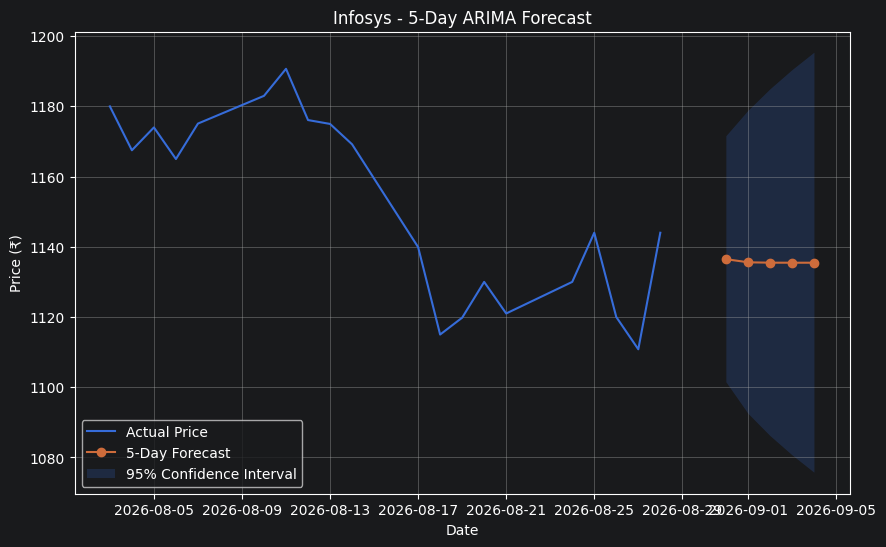

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA


# ==========================================================
# 1. HISTORICAL DATA
# ==========================================================

# Read the NSE CSV file
df = pd.read_csv(
    "Quote-Equity-INFY-EQ-29-07-2026-29-08-2026.csv"
)

# Convert DATE column to datetime
df["DATE"] = pd.to_datetime(
    df["DATE"],
    format="%d-%b-%y"
)

# Sort from oldest to newest
df = df.sort_values("DATE")

# Convert CLOSE from text to numeric
df["CLOSE"] = pd.to_numeric(
    df["CLOSE"].str.replace(",", ""),
    errors="coerce"
)

# Use DATE as index
df.set_index("DATE", inplace=True)

# Remove missing closing prices
df = df.dropna(subset=["CLOSE"])


print("\n========== HISTORICAL DATA ==========")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nNumber of trading days:", len(df))

print("\nDate range:")
print(df.index.min(), "to", df.index.max())


# ==========================================================
# 2. DESCRIPTIVE ANALYTICS
# ==========================================================

print("\n========== DESCRIPTIVE ANALYTICS ==========")

close = df["CLOSE"]

# Mean
mean_price = close.mean()

# Median
median_price = close.median()

# Standard deviation
std_price = close.std()

# Daily percentage return
df["Daily_Return_%"] = close.pct_change() * 100

# Daily volatility
daily_volatility = df["Daily_Return_%"].std()

print(f"Mean Closing Price: ₹{mean_price:.2f}")
print(f"Median Closing Price: ₹{median_price:.2f}")
print(f"Standard Deviation: ₹{std_price:.2f}")
print(f"Daily Volatility: {daily_volatility:.2f}%")


# Compare with Infosys baseline
# Assignment baseline = 1.61%
infosys_baseline = 1.61

print(f"\nInfosys Baseline Volatility: {infosys_baseline:.2f}%")

if daily_volatility > infosys_baseline:
    print("The stock has higher volatility than the Infosys baseline.")
elif daily_volatility < infosys_baseline:
    print("The stock has lower volatility than the Infosys baseline.")
else:
    print("The stock has the same volatility as the Infosys baseline.")


# ==========================================================
# 3. DIAGNOSTIC ANALYTICS
# ==========================================================

print("\n========== DIAGNOSTIC ANALYTICS ==========")


# ----------------------------------------------------------
# 3A. 14-DAY RSI
# ----------------------------------------------------------

delta = close.diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df["RSI_14"] = 100 - (100 / (1 + rs))


# ----------------------------------------------------------
# 3B. 20-DAY EMA
# ----------------------------------------------------------

df["EMA_20"] = close.ewm(
    span=20,
    adjust=False
).mean()


# ----------------------------------------------------------
# 3C. OVERBOUGHT AND OVERSOLD
# ----------------------------------------------------------

overbought = df[df["RSI_14"] > 70]

oversold = df[df["RSI_14"] < 30]


print("\n--- OVERBOUGHT SIGNALS (RSI > 70) ---")

if len(overbought) > 0:
    print(overbought[["CLOSE", "RSI_14"]])
else:
    print("No overbought signals found.")


print("\n--- OVERSOLD SIGNALS (RSI < 30) ---")

if len(oversold) > 0:
    print(oversold[["CLOSE", "RSI_14"]])
else:
    print("No oversold signals found.")


print("\nNumber of overbought signals:", len(overbought))
print("Number of oversold signals:", len(oversold))


# Show latest diagnostic values
print("\n--- LATEST DIAGNOSTIC DATA ---")

print(
    df[
        ["CLOSE", "RSI_14", "EMA_20"]
    ].tail(10)
)


# ==========================================================
# 4. PREDICTIVE ANALYTICS
# ==========================================================

print("\n========== PREDICTIVE ANALYTICS ==========")


# ----------------------------------------------------------
# 4A. HISTORICAL BACKTEST
# ----------------------------------------------------------

# Keep the last 5 days for testing
train = close.iloc[:-5]
test = close.iloc[-5:]


# Fit ARIMA model
model = ARIMA(
    train,
    order=(1, 1, 1)
)

model_fit = model.fit()


# Forecast the 5 test days
backtest_forecast = model_fit.get_forecast(
    steps=5
)

backtest_mean = backtest_forecast.predicted_mean

backtest_ci = backtest_forecast.conf_int(
    alpha=0.05
)


# Create comparison table
backtest_df = pd.DataFrame({
    "Actual": test.values,
    "Forecast": backtest_mean.values,
    "Lower_CI": backtest_ci.iloc[:, 0].values,
    "Upper_CI": backtest_ci.iloc[:, 1].values
}, index=test.index)


print("\n--- ARIMA BACKTEST ---")

print(backtest_df)


# Check whether actual price falls
# inside the 95% confidence interval

backtest_df["Within_CI"] = (
    (backtest_df["Actual"] >= backtest_df["Lower_CI"])
    &
    (backtest_df["Actual"] <= backtest_df["Upper_CI"])
)


print("\n--- CONFIDENCE INTERVAL CHECK ---")

print(
    backtest_df[
        [
            "Actual",
            "Lower_CI",
            "Upper_CI",
            "Within_CI"
        ]
    ]
)


# Calculate coverage percentage
coverage = (
    backtest_df["Within_CI"].mean() * 100
)

print(
    f"\n95% Confidence Interval Coverage: "
    f"{coverage:.2f}%"
)


# ----------------------------------------------------------
# 4B. FINAL MODEL
# ----------------------------------------------------------

# Train ARIMA using all available data

final_model = ARIMA(
    close,
    order=(1, 1, 1)
)

final_model_fit = final_model.fit()


# Forecast next 5 trading days

future_forecast = final_model_fit.get_forecast(
    steps=5
)

future_mean = future_forecast.predicted_mean

future_ci = future_forecast.conf_int(
    alpha=0.05
)


# Create future business dates

future_dates = pd.bdate_range(
    start=close.index[-1] + pd.Timedelta(days=1),
    periods=5
)


# Create forecast DataFrame

forecast_df = pd.DataFrame({
    "Forecast": future_mean.values,
    "Lower_CI": future_ci.iloc[:, 0].values,
    "Upper_CI": future_ci.iloc[:, 1].values
}, index=future_dates)


print("\n--- NEXT 5 TRADING DAY FORECAST ---")

print(forecast_df)


# ==========================================================
# 5. VISUALIZATION
# ==========================================================


# ----------------------------------------------------------
# 5A. HISTORICAL PRICE
# ----------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df.index,
    df["CLOSE"],
    label="INFY Closing Price"
)

plt.title(
    "Infosys - Historical Closing Price"
)

plt.xlabel("Date")
plt.ylabel("Price (₹)")

plt.legend()
plt.grid(True)

plt.show()


# ----------------------------------------------------------
# 5B. PRICE + EMA
# ----------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df.index,
    df["CLOSE"],
    alpha=0.4,
    label="Closing Price"
)

plt.plot(
    df.index,
    df["EMA_20"],
    label="20-Day EMA"
)

plt.title(
    "Infosys - Closing Price and 20-Day EMA"
)

plt.xlabel("Date")
plt.ylabel("Price (₹)")

plt.legend()
plt.grid(True)

plt.show()


# ----------------------------------------------------------
# 5C. RSI
# ----------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    df.index,
    df["RSI_14"],
    label="14-Day RSI"
)

plt.axhline(
    70,
    linestyle="--",
    label="Overbought (70)"
)

plt.axhline(
    30,
    linestyle="--",
    label="Oversold (30)"
)

plt.title(
    "Infosys - 14-Day RSI"
)

plt.xlabel("Date")
plt.ylabel("RSI")

plt.legend()
plt.grid(True)

plt.show()


# ----------------------------------------------------------
# 5D. ARIMA FORECAST
# ----------------------------------------------------------

plt.figure(figsize=(10, 6))

# Recent actual prices
plt.plot(
    close.tail(20).index,
    close.tail(20).values,
    label="Actual Price"
)

# Forecast
plt.plot(
    forecast_df.index,
    forecast_df["Forecast"],
    marker="o",
    label="5-Day Forecast"
)

# 95% confidence interval
plt.fill_between(
    forecast_df.index,
    forecast_df["Lower_CI"],
    forecast_df["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "Infosys - 5-Day ARIMA Forecast"
)

plt.xlabel("Date")
plt.ylabel("Price (₹)")

plt.legend()
plt.grid(True)

plt.show()